In [ ]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange, tqdm
from geometry_tools import lerp
from conditional_gmm import ConditionalGMM
from posterior_manifold import FisherLogPosteriorManifold
from conformal_ebm import optimize_ebm_geodesic
from utils import categorical_entropy, get_random_image, get_random_images, get_random_images_of_classes
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
import torch.distributions as D
from utils import NestedDiagonalGMM
transform = v2.Compose([
    v2.Resize((128, 128), interpolation=v2.InterpolationMode.BICUBIC),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

In [15]:
celeba = torchvision.datasets.CelebA(root='datasets', split='all', transform=transform, download=False)
celeba_loader = DataLoader(celeba, batch_size=16, shuffle=False, num_workers=4)

In [19]:
len(celeba)

202599

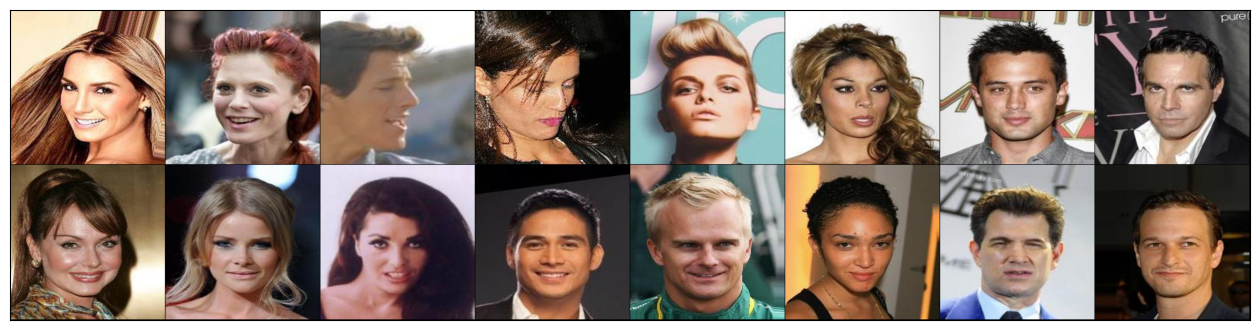

In [16]:
imgs, labels = next(celeba_loader.__iter__())
show_img(make_grid(imgs), figsize=(16, 8))

In [10]:
from pretrained_models import StableDiffusionVAE
vae = StableDiffusionVAE()

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [18]:
vae.encode(imgs[0]).shape

torch.Size([16384])

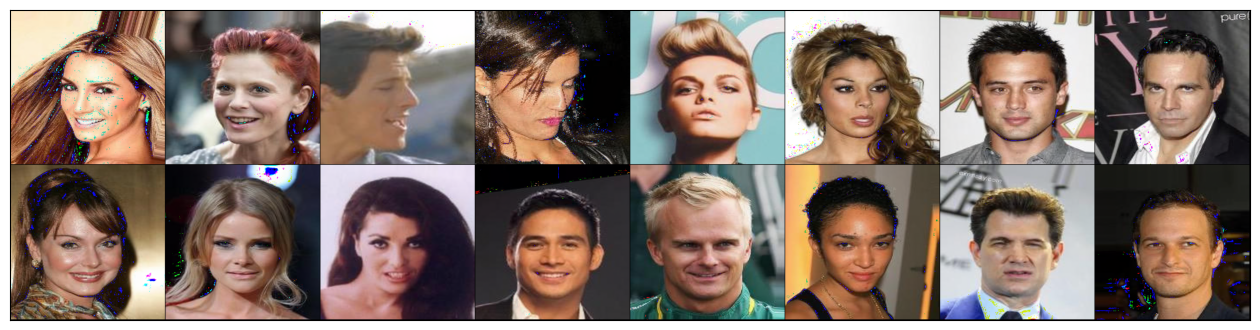

In [17]:
with torch.no_grad():
    reconstructed = vae.reconstruct(imgs)
    show_img(make_grid(reconstructed), figsize=(16, 8))

In [6]:
attribute_names = ["5_o_Clock_Shadow", "Arched_Eyebrows", "Attractive", "Bags_Under_Eyes", "Bald", "Bangs", "Big_Lips", "Big_Nose", "Black_Hair", "Blond_Hair", "Blurry", "Brown_Hair", "Bushy_Eyebrows", "Chubby", "Double_Chin", "Eyeglasses", "Goatee", "Gray_Hair", "Heavy_Makeup", "High_Cheekbones", "Male", "Mouth_Slightly_Open", "Mustache", "Narrow_Eyes", "No_Beard", "Oval_Face", "Pale_Skin", "Pointy_Nose", "Receding_Hairline", "Rosy_Cheeks", "Sideburns", "Smiling", "Straight_Hair", "Wavy_Hair", "Wearing_Earrings", "Wearing_Hat", "Wearing_Lipstick", "Wearing_Necklace", "Wearing_Necktie", "Young"]

In [7]:
from matplotlib.ticker import MultipleLocator
def show_latent_curve(curve: torch.Tensor, title=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=(12, 1.25))
        ax = fig.add_subplot()
    img = make_grid(vae.decode(curve), nrow=curve.shape[0])
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray', extent=(0, 1, 0, 1/len(curve)))
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    # ax.set_xlim(0, 1)
    if title: ax.set_title(title)

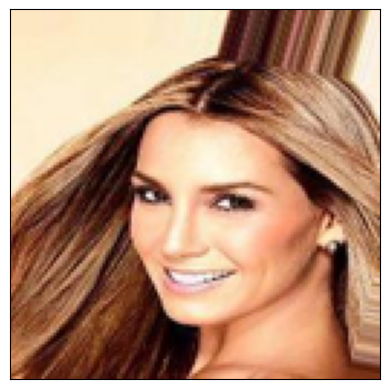

In [8]:
show_img(imgs[0])

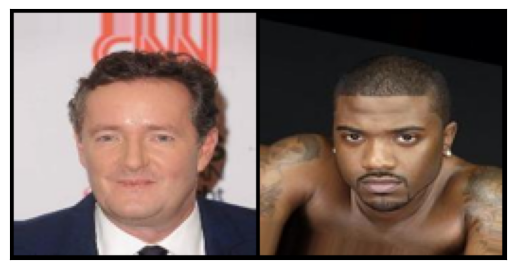

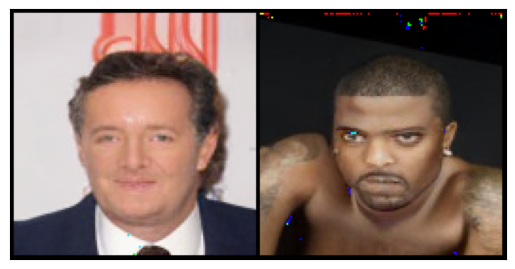

In [38]:
random_imgs = get_random_images(celeba, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

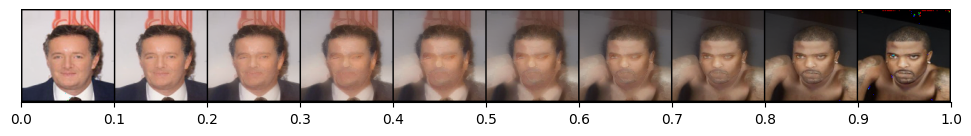

In [40]:
show_latent_curve(lerp(*vae.encode(random_imgs), n=10))

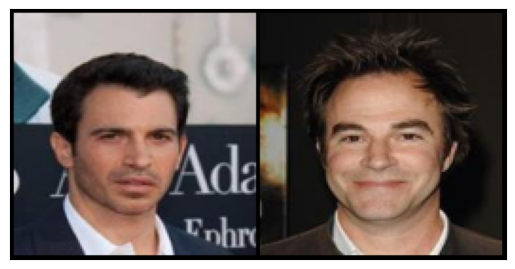

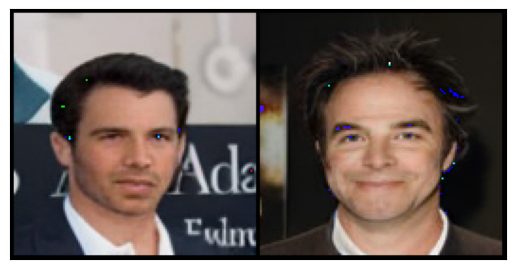

In [13]:
random_imgs = get_random_images(celeba, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

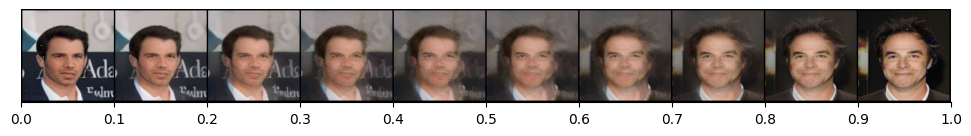

In [14]:
show_latent_curve(lerp(*vae.encode(random_imgs), n=10))

In [ ]:
gmms = torch.load('trained_checkpoints/celeba_stablediff_nested_gmm.pt')

In [ ]:
gmms_torch = [D.MixtureSameFamily(
    mixture_distribution=D.Categorical(torch.as_tensor(gm.weights_, device='cuda', dtype=torch.float32)),
    component_distribution=D.Independent(D.Normal(
        loc=torch.as_tensor(gm.means_, device='cuda', dtype=torch.float32),
        scale=torch.as_tensor(gm.covariances_, device='cuda', dtype=torch.float32)
    ), 1)
) for gm in gmms]

In [9]:
bigger_loader = DataLoader(celeba, batch_size=64, shuffle=False, num_workers=4)
attribute_counts = torch.zeros(40)
for _, labels in bigger_loader:
    for i in range(40):
        attribute_counts[i] += (labels[:, i]).sum()
supweights = attribute_counts / attribute_counts.sum()

In [26]:
nested_gmm_params = torch.load('trained_checkpoints/celeba_stablediff_nested_gmm.pt')
nested_gmm = NestedDiagonalGMM(
    means=nested_gmm_params['means'],
    variances=nested_gmm_params['variances'],
    subweights=nested_gmm_params['subweights'],
    supweights=nested_gmm_params['supweights'],
)

/tmp/user/5678/ipykernel_2681687/1327102347.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nested_gmm_params = torch.load('trained_checkpoints/celeba_stablediff_nested_

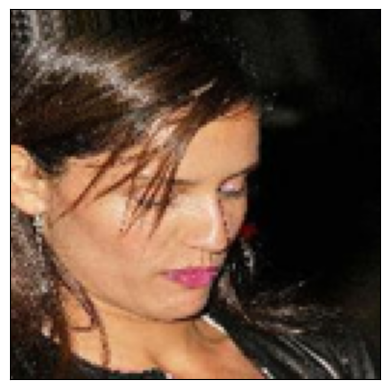

In [46]:
test_img = imgs[3]
show_img(test_img)

In [50]:
vae.encode(test_img.cuda())

tensor([-6.0626,  6.4188,  4.1323,  ..., -2.3573,  0.9219, -5.2672],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [ ]:
lp = nested_gmm.dist.component_distribution.log_prob(vae.encode(test_img.cuda()))
lp 

tensor([-3226.0923, -3278.3560, -3305.4761, -3269.0586, -3201.4292, -3269.5093,
        -3252.9082, -3266.3323, -3164.9875, -3290.9912, -3350.7703, -3274.8337,
        -3148.4727, -3291.8320, -3200.8813, -3238.2283, -3149.2146, -3168.0886,
        -3177.2031, -3279.9570, -3239.6775, -3255.5356, -3208.2441, -3260.2664,
        -3222.9949, -3280.7986, -3312.0342, -3256.3887, -3245.1602, -3137.2476,
        -3208.8132, -3237.3206, -3240.7891, -3306.7817, -3283.9067, -3282.5613,
        -3264.6125, -3261.4062, -3105.7368, -3253.2190], device='cuda:0',
       grad_fn=<LogsumexpBackward0>)

<BarContainer object of 40 artists>

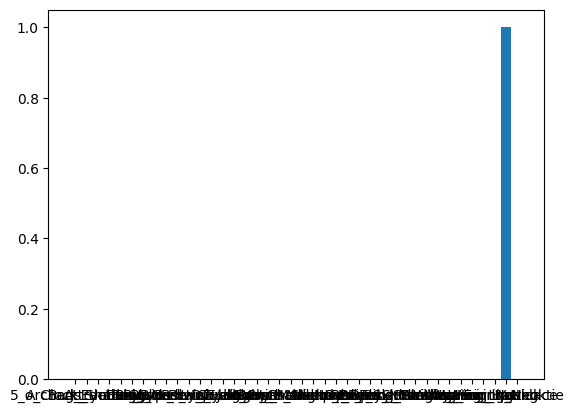

In [47]:
with torch.no_grad():
    test_post = torch.exp(nested_gmm.log_posterior(vae.encode(test_img.cuda()))).cpu()
plt.bar(attribute_names, test_post)

In [48]:
test_post.sort(descending=True).indices

tensor([38, 29, 12, 16,  8, 17, 18, 14,  4, 22, 30, 25, 20, 26, 27, 28, 31, 32,
        33, 34, 35, 36, 37, 39, 24, 23, 21,  0, 19, 15, 13, 11, 10,  9,  7,  6,
         5,  3,  2,  1])

In [ ]:
def log_posterior(x: torch.Tensor) -> torch.Tensor:
    return torch.log_softmax(
        torch.stack([ gm.log_prob(x) for gm in gmms_torch ], dim=-1) + log_prior,
        dim=-1
    )

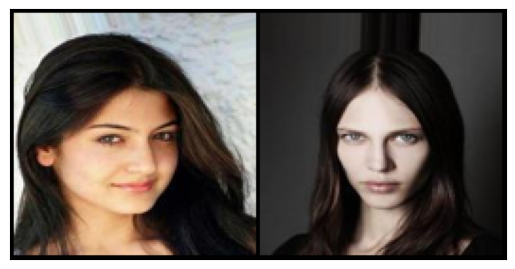

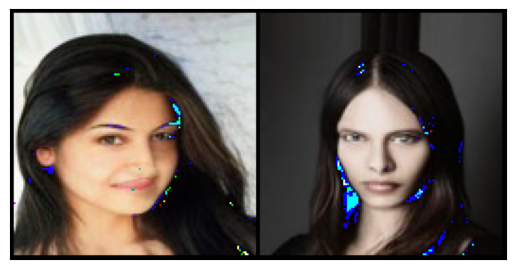

In [54]:
random_imgs = get_random_images(celeba, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))